# Anote 1A — Code Generation Dataset: Load, Clean, Verify, EDA

This section pulls the dataset, cleans it into our unified schema,
verifies test cases execute correctly, and runs a focused EDA pass.

**Pipeline:** Download → Clean into Schema → Verify Ground Truth → EDA & Export




**A little overview of MBPP**

Stands for Mostly Basic Python Problems
- Contains short Python programming problems.

- Each problem includes a natural-language description, reference solution, and test cases.

- Useful for evaluating basic code generation and functional correctness

Main goal for this data is to use for code generation.


## 1. Setup — install packages

In [85]:
import os
import sys
import json
import re
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress non-critical warnings
warnings.filterwarnings("ignore")

# Configure Matplotlib and Seaborn visualization styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
plt.rcParams["savefig.dpi"] = 300

# Directory Infrastructure Setup
DATA_DIR = Path("./data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = DATA_DIR / "reports"

for path in [RAW_DIR, PROCESSED_DIR, REPORTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("[INFO] Environment configured and output directories initialized.")

[INFO] Environment configured and output directories initialized.


# 2. Download Dataset

In [86]:
MBPP_BASE_URL = "hf://datasets/claudios/google-research-datasets__mbpp/"

splits = {
    'train': 'sanitized/train-00000-of-00001.parquet',
    'test': 'sanitized/test-00000-of-00001.parquet',
    'validation': 'sanitized/validation-00000-of-00001.parquet',
    'prompt': 'sanitized/prompt-00000-of-00001.parquet'
}

print("[INFO] Ingesting MBPP (sanitized) raw parquet files...")
df_mbpp_train = pd.read_parquet(MBPP_BASE_URL + splits["train"])
df_mbpp_test = pd.read_parquet(MBPP_BASE_URL + splits["test"])

# Concatenate train and test splits for full pipeline evaluation.
# NOTE: the sanitized `validation` (43) and `prompt` (7) splits are intentionally excluded;
# `prompt` holds few-shot examples and `validation` is reserved for tuning.
df_mbpp_raw = pd.concat([df_mbpp_train, df_mbpp_test], ignore_index=True)

print(f"[INFO] Raw MBPP loaded successfully!")
print(f"       Total Records: {len(df_mbpp_raw)} | Train: {len(df_mbpp_train)} | Test: {len(df_mbpp_test)}")

[INFO] Ingesting MBPP (sanitized) raw parquet files...
[INFO] Raw MBPP loaded successfully!
       Total Records: 377 | Train: 120 | Test: 257


# 3. Clean and sanitze into unified schema

In [87]:
import ast

def extract_signature(code: str, tests) -> tuple:
    """
    Returns (entry_point, signature) for the function the tests actually call.

    reference_code may start with imports (e.g. `import math`) or define helper
    functions before the target, so we parse the code and keep the top-level
    def whose name appears as a call in the test asserts.
    """
    called = set(re.findall(r"\b([A-Za-z_]\w*)\s*\(", " ".join(tests)))
    hits = [node for node in ast.parse(code).body
            if isinstance(node, ast.FunctionDef) and node.name in called]
    if len(hits) != 1:
        raise ValueError(f"Expected one tested function, found {[n.name for n in hits]}")
    fn = hits[0]
    return fn.name, f"def {fn.name}({ast.unparse(fn.args)}):"


def clean_mbpp(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardizes MBPP records into a unified dataset schema with schema-drift protection.
    Schema Output: [task_id, dataset_name, task_type, prompt, reference_code, test_cases,
                    test_format, entry_point, signature, test_imports]
    """
    cleaned = pd.DataFrame()

    # Task ID Formatting
    if "task_id" in df.columns:
        cleaned["task_id"] = df["task_id"].apply(lambda x: f"MBPP/{x}")
    else:
        cleaned["task_id"] = [f"MBPP/{i}" for i in range(len(df))]

    cleaned["dataset_name"] = "MBPP"
    cleaned["task_type"] = "Code Generation"

    # Dynamic column mapping with fallback mechanisms
    prompt_col = next((col for col in ["prompt", "text", "description"] if col in df.columns), None)
    if prompt_col:
        cleaned["prompt"] = df[prompt_col].astype(str).str.strip()
    else:
        raise KeyError(f"Missing prompt column. Available columns: {list(df.columns)}")

    code_col = next((col for col in ["code", "canonical_solution"] if col in df.columns), None)
    if code_col:
        cleaned["reference_code"] = df[code_col].astype(str).str.strip()
    else:
        cleaned["reference_code"] = ""

    test_col = next((col for col in ["test_list", "test", "test_cases"] if col in df.columns), None)
    if test_col and test_col in df.columns:
        cleaned["test_cases"] = df[test_col]
    else:
        cleaned["test_cases"] = None
    cleaned["test_format"] = "assert_list"

    # The prompt never names the function, but the asserts call it by name.
    # Take the signature from reference_code and append it to the prompt.
    sigs = [extract_signature(code, list(tests))
            for code, tests in zip(cleaned["reference_code"], cleaned["test_cases"])]
    cleaned["entry_point"] = [name for name, _ in sigs]
    cleaned["signature"] = [sig for _, sig in sigs]
    cleaned["prompt"] = cleaned["prompt"] + "\n\n" + cleaned["signature"]

    # Sanitized split names this column `test_imports` (a list, e.g. ["import math"]);
    # the full split names it `test_setup_code` (a string). Normalize to one string.
    imports_col = next((col for col in ["test_imports", "test_setup_code"] if col in df.columns), None)
    if imports_col:
        cleaned["test_imports"] = df[imports_col].apply(
            lambda x: "\n".join(x) if isinstance(x, (list, np.ndarray)) else str(x or "")
        )
    else:
        cleaned["test_imports"] = ""

    return cleaned

df_mbpp_clean = clean_mbpp(df_mbpp_raw)
print("[INFO] Dataset transformed into unified schema successfully!")
print(f"[INFO] Rows needing test_imports: {(df_mbpp_clean['test_imports'] != '').sum()}")
df_mbpp_clean.head()

[INFO] Dataset transformed into unified schema successfully!
[INFO] Rows needing test_imports: 13


,task_id,dataset_name,task_type,prompt,reference_code,test_cases,test_format,entry_point,signature,test_imports
0,MBPP/602,MBPP,Code Generation,Write a python function to find the first repe...,"def first_repeated_char(str1):\n for index,c ...","[assert first_repeated_char(""abcabc"") == ""a"", ...",assert_list,first_repeated_char,def first_repeated_char(str1):,
1,MBPP/603,MBPP,Code Generation,Write a function to get all lucid numbers smal...,def get_ludic(n):\n\tludics = []\n\tfor i in r...,"[assert get_ludic(10) == [1, 2, 3, 5, 7], asse...",assert_list,get_ludic,def get_ludic(n):,
2,MBPP/604,MBPP,Code Generation,Write a function to reverse words seperated by...,def reverse_words(s):\n return ' '.join...,"[assert reverse_words(""python program"")==(""pro...",assert_list,reverse_words,def reverse_words(s):,
3,MBPP/605,MBPP,Code Generation,Write a function to check if the given integer...,def prime_num(num):\n if num >=1:\n for i i...,"[assert prime_num(13)==True, assert prime_num(...",assert_list,prime_num,def prime_num(num):,
4,MBPP/606,MBPP,Code Generation,Write a function to convert degrees to radians...,import math\ndef radian_degree(degree):\n radi...,"[assert radian_degree(90)==1.5707963267948966,...",assert_list,radian_degree,def radian_degree(degree):,


# 4. Verify functional correctness
Ground truth refers to information known to be real, accurate, and correct based on objective real-world evidence. It serves as the target or benchmark against which AI models and algorithms are trained, tested, and evaluated.

In [88]:
def verify_solution(code: str, test_cases: list, setup_code: str = "") -> dict:
    """
    Executes solution code against assertion test cases in an isolated namespace.
    """
    exec_globals = {}

    try:
        # Step 1: Run setup/imports if available
        if setup_code and isinstance(setup_code, str) and setup_code.strip():
            exec(setup_code, exec_globals)

        # Step 2: Define reference solution
        exec(code, exec_globals)

        # Step 3: Run assertions
        if isinstance(test_cases, (list, np.ndarray)):
            for test in test_cases:
                exec(test, exec_globals)

        return {"passed": True, "error": None}
    except Exception as e:
        return {"passed": False, "error": f"{type(e).__name__}: {str(e)}"}

print("[INFO] Verifying functional correctness of reference solutions...")
verification_results = []

for idx, row in df_mbpp_clean.iterrows():
    result = verify_solution(
        code=row["reference_code"],
        test_cases=row["test_cases"],
        setup_code=row["test_imports"]
    )
    verification_results.append(result)

df_mbpp_clean["is_valid_reference"] = [r["passed"] for r in verification_results]
df_mbpp_clean["verification_error"] = [r["error"] for r in verification_results]

pass_rate = (df_mbpp_clean["is_valid_reference"].sum() / len(df_mbpp_clean)) * 100
print(f"\n==================================================")
print(f" Ground Truth Verification Pass Rate: {pass_rate:.2f}%")
print(f" Verified Tasks: {df_mbpp_clean['is_valid_reference'].sum()} / {len(df_mbpp_clean)}")
print(f"==================================================\n")

[INFO] Verifying functional correctness of reference solutions...

 Ground Truth Verification Pass Rate: 100.00%
 Verified Tasks: 377 / 377



# 5. Exploratory Data Analysis (EDA)

[INFO] Generating dataset metrics and distribution profiles...
Tasks with exact float equality in asserts: 22 / 377
--- MBPP Summary Statistics ---
                 Count   Mean  Std Dev  Min  Median   Max
prompt_word_len  377.0  19.21     7.35  9.0    18.0  81.0
code_word_len    377.0  21.18    16.31  4.0    16.0  91.0
code_lines       377.0   5.89     4.13  2.0     5.0  26.0
num_test_cases   377.0   3.10     0.42  3.0     3.0   7.0


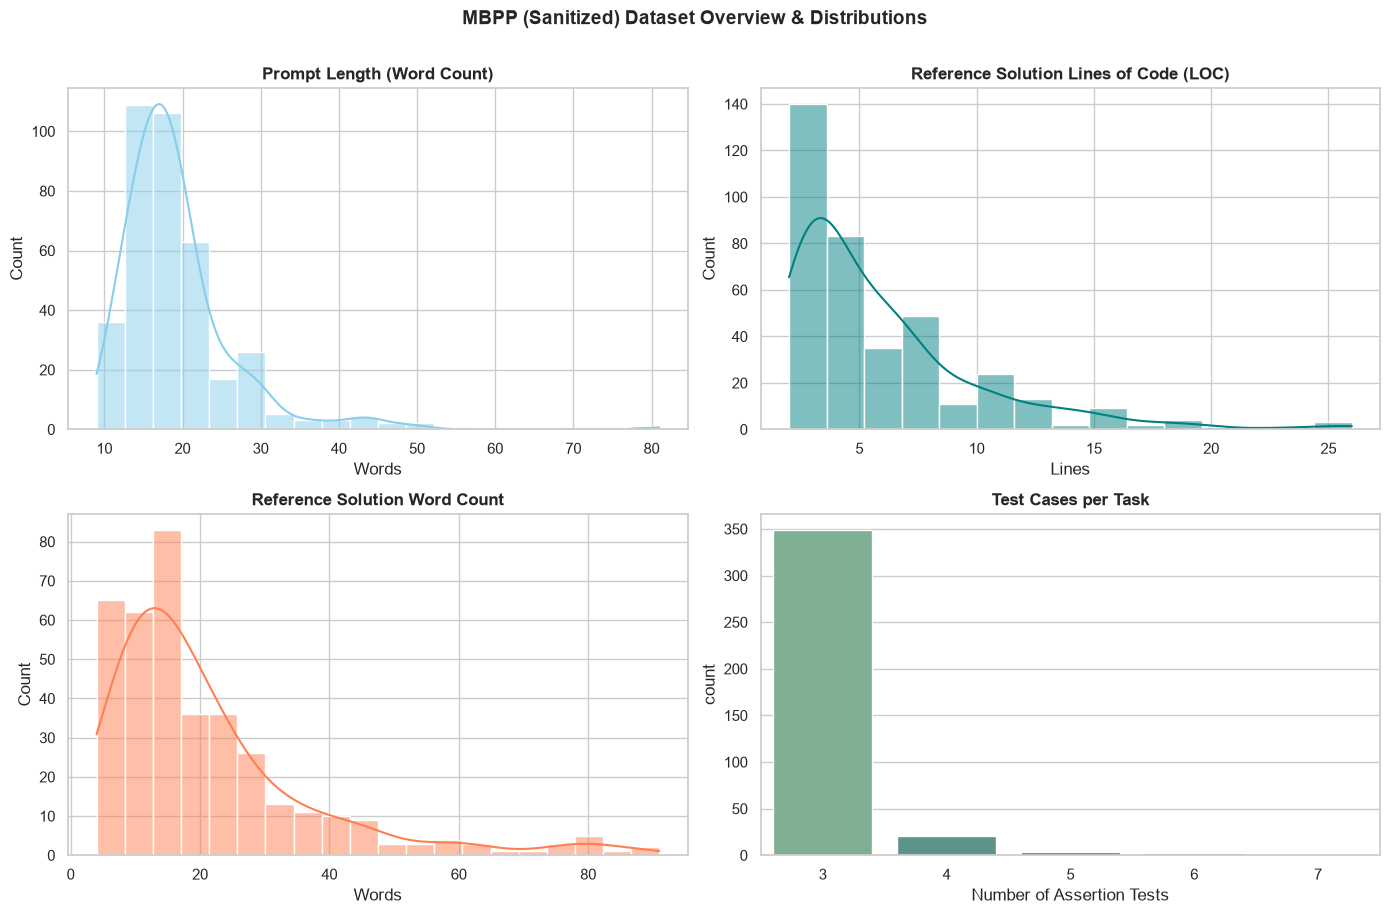

In [89]:
print("[INFO] Generating dataset metrics and distribution profiles...")

# Compute metrics for text length and assertion counts
df_eda = df_mbpp_clean.copy()
df_eda["prompt_word_len"] = df_eda["prompt"].astype(str).str.split().str.len()
df_eda["code_word_len"] = df_eda["reference_code"].astype(str).str.split().str.len()
df_eda["code_lines"] = df_eda["reference_code"].astype(str).str.split("\n").str.len()
df_eda["num_test_cases"] = df_eda["test_cases"].apply(
    lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0
)

def has_float_equality(tests) -> bool:
    """True if any assert compares against a float literal with == (brittle to rounding)."""
    for test in tests:
        for node in ast.walk(ast.parse(test)):
            if isinstance(node, ast.Compare) and any(isinstance(op, ast.Eq) for op in node.ops):
                if any(isinstance(n, ast.Constant) and isinstance(n.value, float)
                       for side in [node.left, *node.comparators] for n in ast.walk(side)):
                    return True
    return False

# NOTE: exact float equality in asserts can fail correct solutions that round differently.
# Flagged here only; tests are left unchanged.
df_eda["has_float_equality"] = df_eda["test_cases"].apply(lambda x: has_float_equality(list(x)))
print(f"Tasks with exact float equality in asserts: {df_eda['has_float_equality'].sum()} / {len(df_eda)}")

# Display Summary Statistics
metrics = ["prompt_word_len", "code_word_len", "code_lines", "num_test_cases"]
stats_df = df_eda[metrics].describe().T[["count", "mean", "std", "min", "50%", "max"]]
stats_df.columns = ["Count", "Mean", "Std Dev", "Min", "Median", "Max"]

print("--- MBPP Summary Statistics ---")
print(stats_df.round(2).to_string())

# Export summary statistics report
stats_df.to_csv(REPORTS_DIR / "mbpp_summary_statistics.csv")

# Plot metric distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df_eda["prompt_word_len"], kde=True, ax=axes[0, 0], color="skyblue", bins=20)
axes[0, 0].set_title("Prompt Length (Word Count)", fontweight="bold")
axes[0, 0].set_xlabel("Words")

sns.histplot(df_eda["code_lines"], kde=True, ax=axes[0, 1], color="teal", bins=15)
axes[0, 1].set_title("Reference Solution Lines of Code (LOC)", fontweight="bold")
axes[0, 1].set_xlabel("Lines")

sns.histplot(df_eda["code_word_len"], kde=True, ax=axes[1, 0], color="coral", bins=20)
axes[1, 0].set_title("Reference Solution Word Count", fontweight="bold")
axes[1, 0].set_xlabel("Words")

sns.countplot(data=df_eda, x="num_test_cases", ax=axes[1, 1], palette="crest")
axes[1, 1].set_title("Test Cases per Task", fontweight="bold")
axes[1, 1].set_xlabel("Number of Assertion Tests")

plt.suptitle("MBPP (Sanitized) Dataset Overview & Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()

plt.savefig(REPORTS_DIR / "mbpp_eda_distributions.png", bbox_inches="tight")
plt.show()


# 6. Processed Data and Export to file

In [90]:
def test_cases_to_json(test_cases):
    """Convert a test_cases value (list or numpy array) into a JSON string.

    Parquet can have trouble serializing nested lists/arrays, so we store
    test cases as JSON strings in a separate column.
    """
    if isinstance(test_cases, np.ndarray):
        test_cases = test_cases.tolist()
    return json.dumps(test_cases)


# Filter for valid verified tasks for model benchmark evaluations
df_mbpp_verified = df_mbpp_clean[df_mbpp_clean["is_valid_reference"] == True].reset_index(drop=True)

# Format test_cases list as JSON strings for parquet serialization compatibility
df_mbpp_clean["test_cases_json"] = df_mbpp_clean["test_cases"].apply(test_cases_to_json)
df_mbpp_verified["test_cases_json"] = df_mbpp_verified["test_cases"].apply(test_cases_to_json)

# Export complete and verified datasets
df_mbpp_clean.to_parquet(PROCESSED_DIR / "mbpp_sanitized_full.parquet", index=False)
df_mbpp_verified.to_parquet(PROCESSED_DIR / "mbpp_sanitized_verified.parquet", index=False)
df_mbpp_verified.to_csv(PROCESSED_DIR / "mbpp_sanitized_verified.csv", index=False)

print(f"[SUCCESS] Artifacts stored in '{PROCESSED_DIR.resolve()}':")
print(f"          - Full Dataset: mbpp_sanitized_full.parquet ({len(df_mbpp_clean)} rows)")
print(f"          - Verified Dataset: mbpp_sanitized_verified.parquet ({len(df_mbpp_verified)} rows)")

[SUCCESS] Artifacts stored in '/Users/diadana/Documents/GitHub/Anote-1A-building-high-quality-datasets-and-evaluation-frameworks-for-ai-coding-assistants/notebooks/data/processed':
          - Full Dataset: mbpp_sanitized_full.parquet (377 rows)
          - Verified Dataset: mbpp_sanitized_verified.parquet (377 rows)


# -- HumanEval Dataset --

# 1. Download Dataset

In [91]:

df_humaneval_raw = pd.read_parquet("hf://datasets/openai/openai_humaneval/openai_humaneval/test-00000-of-00001.parquet")
print(f"[INFO] Raw HumanEval loaded! Total Records: {len(df_humaneval_raw)}")

[INFO] Raw HumanEval loaded! Total Records: 164


# Clean and sanitze into unified schema

In [92]:
def extract_humaneval_signature(prompt: str, entry_point: str) -> str:
    """Returns the `def` line (with type hints) of the entry_point function in the prompt stub."""
    fn = next(node for node in ast.parse(prompt).body
              if isinstance(node, ast.FunctionDef) and node.name == entry_point)
    returns = f" -> {ast.unparse(fn.returns)}" if fn.returns else ""
    return f"def {fn.name}({ast.unparse(fn.args)}){returns}:"


def clean_humaneval(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardizes HumanEval records into the same schema as MBPP.
    Schema Output: [task_id, dataset_name, task_type, prompt, reference_code, test_cases,
                    test_format, entry_point, signature, test_imports]
    """
    cleaned = pd.DataFrame()

    cleaned["task_id"] = df["task_id"]
    cleaned["dataset_name"] = "HumanEval"
    cleaned["task_type"] = "Code Generation"

    cleaned["prompt"] = df["prompt"]

    # canonical_solution is only the indented function body, so it can't run on its own.
    # prompt + body gives the complete function (plus any imports/helpers defined in the prompt),
    # matching MBPP where reference_code is a full runnable solution.
    cleaned["reference_code"] = df["prompt"] + df["canonical_solution"]

    # test is a `check(candidate)` definition; append the call so it runs like an MBPP assert.
    cleaned["test_cases"] = [
        [test + f"\n\ncheck({entry_point})\n"]
        for test, entry_point in zip(df["test"], df["entry_point"])
    ]
    cleaned["test_format"] = "check_fn"

    cleaned["entry_point"] = df["entry_point"]
    cleaned["signature"] = [
        extract_humaneval_signature(prompt, entry_point)
        for prompt, entry_point in zip(df["prompt"], df["entry_point"])
    ]
    # Imports live in the prompt itself, so they are already part of reference_code.
    cleaned["test_imports"] = ""

    return cleaned

df_humaneval_clean = clean_humaneval(df_humaneval_raw)
print("[INFO] HumanEval cleaned successfully!")
df_humaneval_clean.head()

[INFO] HumanEval cleaned successfully!


,task_id,dataset_name,task_type,prompt,reference_code,test_cases,test_format,entry_point,signature,test_imports
0,HumanEval/0,HumanEval,Code Generation,from typing import List\n\n\ndef has_close_ele...,from typing import List\n\n\ndef has_close_ele...,"[\n\nMETADATA = {\n 'author': 'jt',\n 'd...",check_fn,has_close_elements,"def has_close_elements(numbers: List[float], t...",
1,HumanEval/1,HumanEval,Code Generation,from typing import List\n\n\ndef separate_pare...,from typing import List\n\n\ndef separate_pare...,"[\n\nMETADATA = {\n 'author': 'jt',\n 'd...",check_fn,separate_paren_groups,def separate_paren_groups(paren_string: str) -...,
2,HumanEval/2,HumanEval,Code Generation,\n\ndef truncate_number(number: float) -> floa...,\n\ndef truncate_number(number: float) -> floa...,"[\n\nMETADATA = {\n 'author': 'jt',\n 'd...",check_fn,truncate_number,def truncate_number(number: float) -> float:,
3,HumanEval/3,HumanEval,Code Generation,from typing import List\n\n\ndef below_zero(op...,from typing import List\n\n\ndef below_zero(op...,"[\n\nMETADATA = {\n 'author': 'jt',\n 'd...",check_fn,below_zero,def below_zero(operations: List[int]) -> bool:,
4,HumanEval/4,HumanEval,Code Generation,from typing import List\n\n\ndef mean_absolute...,from typing import List\n\n\ndef mean_absolute...,"[\n\nMETADATA = {\n 'author': 'jt',\n 'd...",check_fn,mean_absolute_deviation,def mean_absolute_deviation(numbers: List[floa...,


# Verify functional correctness

In [93]:
# reference_code is now a full function and test_cases a list of executable strings,
# so the same verify_solution used for MBPP works here.
print("[INFO] Verifying functional correctness of reference solutions...")
verification_results = [
    verify_solution(code=row["reference_code"], test_cases=row["test_cases"], setup_code=row["test_imports"])
    for _, row in df_humaneval_clean.iterrows()
]

df_humaneval_clean["is_valid_reference"] = [r["passed"] for r in verification_results]
df_humaneval_clean["verification_error"] = [r["error"] for r in verification_results]

pass_rate = (df_humaneval_clean["is_valid_reference"].sum() / len(df_humaneval_clean)) * 100
print(f"\n==================================================")
print(f" Ground Truth Verification Pass Rate: {pass_rate:.2f}%")
print(f" Verified Tasks: {df_humaneval_clean['is_valid_reference'].sum()} / {len(df_humaneval_clean)}")
print(f"==================================================\n")

[INFO] Verifying functional correctness of reference solutions...

 Ground Truth Verification Pass Rate: 100.00%
 Verified Tasks: 164 / 164



# Exploratory Data Analysis (EDA)

**Comparability note:** HumanEval prompts are code stubs (imports + signature + docstring with examples) while MBPP prompts are one prose sentence plus a signature, so prompt word counts are not directly comparable. HumanEval `reference_code` also includes the prompt's docstring, which inflates its LOC relative to MBPP.

[INFO] Generating dataset metrics and distribution profiles...
--- HumanEval Summary Statistics ---
                 Count   Mean  Std Dev   Min  Median    Max
prompt_word_len  164.0  67.72    38.67  17.0    60.0  249.0
code_word_len    164.0  92.10    47.33  20.0    84.0  327.0
code_lines       164.0  21.49     8.55   9.0    20.0   59.0
num_test_cases   164.0   7.20     3.72   1.0     7.0   26.0


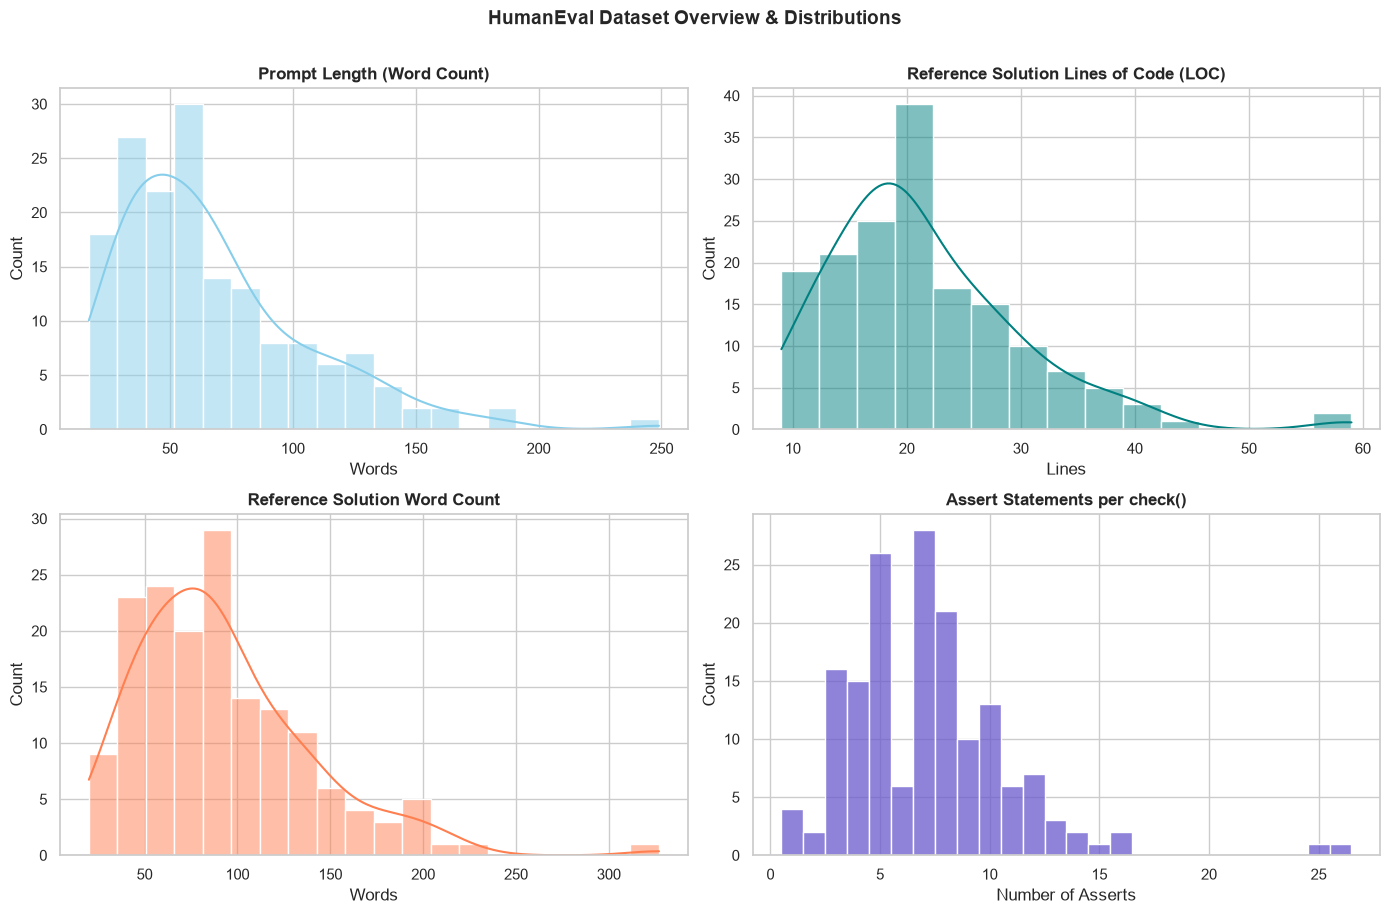

In [94]:
print("[INFO] Generating dataset metrics and distribution profiles...")

df_he_eda = df_humaneval_clean.copy()
df_he_eda["prompt_word_len"] = df_he_eda["prompt"].astype(str).str.split().str.len()
df_he_eda["code_word_len"] = df_he_eda["reference_code"].astype(str).str.split().str.len()
df_he_eda["code_lines"] = df_he_eda["reference_code"].astype(str).str.split("\n").str.len()
# Each task has a single check() function, so count the assert statements inside it.
# Asserts inside loops count once, so this is a lower bound on executed checks.
df_he_eda["num_test_cases"] = df_he_eda["test_cases"].apply(
    lambda tests: sum(isinstance(node, ast.Assert) for t in tests for node in ast.walk(ast.parse(t)))
)

metrics = ["prompt_word_len", "code_word_len", "code_lines", "num_test_cases"]
he_stats_df = df_he_eda[metrics].describe().T[["count", "mean", "std", "min", "50%", "max"]]
he_stats_df.columns = ["Count", "Mean", "Std Dev", "Min", "Median", "Max"]

print("--- HumanEval Summary Statistics ---")
print(he_stats_df.round(2).to_string())

he_stats_df.to_csv(REPORTS_DIR / "humaneval_summary_statistics.csv")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df_he_eda["prompt_word_len"], kde=True, ax=axes[0, 0], color="skyblue", bins=20)
axes[0, 0].set_title("Prompt Length (Word Count)", fontweight="bold")
axes[0, 0].set_xlabel("Words")

sns.histplot(df_he_eda["code_lines"], kde=True, ax=axes[0, 1], color="teal", bins=15)
axes[0, 1].set_title("Reference Solution Lines of Code (LOC)", fontweight="bold")
axes[0, 1].set_xlabel("Lines")

sns.histplot(df_he_eda["code_word_len"], kde=True, ax=axes[1, 0], color="coral", bins=20)
axes[1, 0].set_title("Reference Solution Word Count", fontweight="bold")
axes[1, 0].set_xlabel("Words")

sns.histplot(df_he_eda["num_test_cases"], ax=axes[1, 1], color="slateblue", discrete=True)
axes[1, 1].set_title("Assert Statements per check()", fontweight="bold")
axes[1, 1].set_xlabel("Number of Asserts")

plt.suptitle("HumanEval Dataset Overview & Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()

plt.savefig(REPORTS_DIR / "humaneval_eda_distributions.png", bbox_inches="tight")
plt.show()

# Processed Data and Export to file

In [95]:
df_humaneval_verified = df_humaneval_clean[df_humaneval_clean["is_valid_reference"] == True].reset_index(drop=True)

df_humaneval_clean["test_cases_json"] = df_humaneval_clean["test_cases"].apply(test_cases_to_json)
df_humaneval_verified["test_cases_json"] = df_humaneval_verified["test_cases"].apply(test_cases_to_json)

df_humaneval_clean.to_parquet(PROCESSED_DIR / "humaneval_full.parquet", index=False)
df_humaneval_verified.to_parquet(PROCESSED_DIR / "humaneval_verified.parquet", index=False)
df_humaneval_verified.to_csv(PROCESSED_DIR / "humaneval_verified.csv", index=False)

print(f"[SUCCESS] Artifacts stored in '{PROCESSED_DIR.resolve()}':")
print(f"          - Full Dataset: humaneval_full.parquet ({len(df_humaneval_clean)} rows)")
print(f"          - Verified Dataset: humaneval_verified.parquet ({len(df_humaneval_verified)} rows)")

[SUCCESS] Artifacts stored in '/Users/diadana/Documents/GitHub/Anote-1A-building-high-quality-datasets-and-evaluation-frameworks-for-ai-coding-assistants/notebooks/data/processed':
          - Full Dataset: humaneval_full.parquet (164 rows)
          - Verified Dataset: humaneval_verified.parquet (164 rows)


**Suggestion: HumanEval+ (EvalPlus)**

HumanEval's original tests are thin for some tasks (a few `check()` functions have only 1–3 asserts), so incorrect solutions can pass by luck. [HumanEval+](https://github.com/evalplus/evalplus) keeps the same 164 problems but adds far more tests per task (roughly 80× the original), along with fixes to a few faulty reference solutions. Swapping in its tests would make HumanEval a stricter Pass@1 signal without changing the prompts. To discuss with the team before adopting.

# -- LiveCodeBench Dataset --

**A little overview of LiveCodeBench (test6)**
- Contest problems from AtCoder and LeetCode, each tagged with its contest date and difficulty.
- AtCoder problems are full programs that read stdin and print to stdout; LeetCode problems implement a method on a given `class Solution`.
- Each task has a few public example tests and a larger set of private (hidden) tests. There are no reference solutions.
- Main use: harder code generation with headroom, and contamination control by filtering on `contest_date`.

Moved here from `preprocess_livecodebench.ipynb` so all code generation datasets share one pipeline and schema.

# 1. Download Dataset

In [96]:
from datasets import load_dataset

# test6 is one release slice of LiveCodeBench (code_generation_lite); later slices hold newer contest problems.
LCB_URL = "https://huggingface.co/datasets/livecodebench/code_generation_lite/resolve/main/test6.jsonl"

df_lcb_raw = load_dataset("json", data_files=LCB_URL)["train"].to_pandas()
print(f"[INFO] Raw LiveCodeBench loaded! Total Records: {len(df_lcb_raw)}")

[INFO] Raw LiveCodeBench loaded! Total Records: 175


# Clean and sanitize into unified schema

In [97]:
import base64
import pickle
import zlib

# LiveCodeBench's official formatting instructions, one per problem style.
LCB_STDIN_INSTRUCTION = (
    "Read the inputs from stdin, solve the problem and write the answer to stdout "
    "(do not directly test on the sample inputs)."
)
LCB_STARTER_INSTRUCTION = "Use the following starter code to write the solution to the problem."

# Each test's `testtype`: "stdin" (AtCoder, full program) or "functional" (LeetCode, class Solution method)
TEST_FORMATS = {"stdin": "stdin_io", "functional": "functional_io"}


def parse_public_tests(raw) -> list:
    """public_test_cases is always a plain JSON string."""
    try:
        return json.loads(raw)
    except (TypeError, json.JSONDecodeError):
        return []


def parse_private_tests(raw) -> list:
    """
    private_test_cases is plain JSON or, for large test sets, a base64 + zlib + pickled JSON blob.
    Tries plain JSON first, then the compressed path. Returns [] if neither works.
    """
    try:
        return json.loads(raw)
    except (TypeError, json.JSONDecodeError):
        pass
    try:
        # pickle can run code when loading; acceptable here since this is LCB's documented format.
        return json.loads(pickle.loads(zlib.decompress(base64.b64decode(raw))))
    except Exception:
        return []


def build_lcb_prompt(question: str, starter_code: str) -> str:
    """Problem statement + the answer-format instruction (+ starter code for LeetCode)."""
    if starter_code.strip():
        return f"{question.strip()}\n\n{LCB_STARTER_INSTRUCTION}\n\n{starter_code.strip()}"
    return f"{question.strip()}\n\n{LCB_STDIN_INSTRUCTION}"


def lcb_test_format(tests: list) -> str:
    """One format per task; mixed or missing testtypes become "unknown" and get flagged later."""
    types = {t.get("testtype") for t in tests}
    return TEST_FORMATS.get(types.pop(), "unknown") if len(types) == 1 else "unknown"


def clean_lcb(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardizes LiveCodeBench records into the same schema as MBPP and HumanEval.
    Schema Output: [task_id, dataset_name, task_type, prompt, reference_code, test_cases,
                    test_format, entry_point, signature, test_imports,
                    platform, contest_id, contest_date, difficulty, private_test_cases]

    test_cases holds the public tests only. Private tests stay in their own column and are
    exported to a separate file, because decompressed they are far too large for git.
    """
    df = df.copy()
    # Empty starter_code means "no scaffold" (stdin problems), not missing data
    df["starter_code"] = df["starter_code"].fillna("")

    # Drop rows with no statement or no public tests, then duplicate problems
    df = df.replace({"question_content": {"": pd.NA}, "public_test_cases": {"": pd.NA}})
    df = df.dropna(subset=["question_content", "public_test_cases"])
    df = df.drop_duplicates(subset=["question_id"]).reset_index(drop=True)

    cleaned = pd.DataFrame()
    cleaned["task_id"] = "LCB/" + df["question_id"].astype(str)
    cleaned["dataset_name"] = "LiveCodeBench"
    cleaned["task_type"] = "Code Generation"
    cleaned["prompt"] = [build_lcb_prompt(q, s) for q, s in zip(df["question_content"], df["starter_code"])]
    cleaned["reference_code"] = ""  # LiveCodeBench ships no reference solutions

    cleaned["test_cases"] = df["public_test_cases"].apply(parse_public_tests)
    private_tests = df["private_test_cases"].apply(parse_private_tests)
    cleaned["test_format"] = [lcb_test_format(pub + priv) for pub, priv in zip(cleaned["test_cases"], private_tests)]

    # metadata is a JSON string; for LeetCode it holds func_name, the method the tests call
    cleaned["entry_point"] = df["metadata"].apply(lambda m: json.loads(m or "{}").get("func_name", ""))
    cleaned["signature"] = df["starter_code"].str.strip()
    cleaned["test_imports"] = ""

    # LCB-specific fields: contest_date enables filtering out problems older than a model's cutoff
    cleaned["platform"] = df["platform"]
    cleaned["contest_id"] = df["contest_id"]
    cleaned["contest_date"] = pd.to_datetime(df["contest_date"]).dt.strftime("%Y-%m-%d")
    cleaned["difficulty"] = df["difficulty"]

    cleaned["private_test_cases"] = private_tests
    return cleaned


df_lcb_clean = clean_lcb(df_lcb_raw)
print("[INFO] LiveCodeBench cleaned into unified schema successfully!")
print(f"[INFO] Tasks kept: {len(df_lcb_clean)} / {len(df_lcb_raw)}")
print(df_lcb_clean["test_format"].value_counts().to_string())
df_lcb_clean.drop(columns="private_test_cases").head()

[INFO] LiveCodeBench cleaned into unified schema successfully!
[INFO] Tasks kept: 175 / 175
test_format
stdin_io         112
functional_io     63


,task_id,dataset_name,task_type,prompt,reference_code,test_cases,test_format,entry_point,signature,test_imports,platform,contest_id,contest_date,difficulty
0,LCB/abc387_b,LiveCodeBench,Code Generation,Among the 81 integers that appear in the 9-by-...,,"[{'input': '1', 'output': '2024', 'testtype': ...",stdin_io,,,,atcoder,abc387,2025-01-04,easy
1,LCB/abc387_f,LiveCodeBench,Code Generation,"You are given positive integers N, M, and a se...",,"[{'input': '3 3 2 1 1', 'output': '6', 'testty...",stdin_io,,,,atcoder,abc387,2025-01-04,hard
2,LCB/abc387_a,LiveCodeBench,Code Generation,You are given two positive integers A and B.\n...,,"[{'input': '20 25', 'output': '2025', 'testtyp...",stdin_io,,,,atcoder,abc387,2025-01-04,easy
3,LCB/abc387_c,LiveCodeBench,Code Generation,A positive integer not less than 10 whose top ...,,"[{'input': '97 210', 'output': '6', 'testtype'...",stdin_io,,,,atcoder,abc387,2025-01-04,medium
4,LCB/abc388_d,LiveCodeBench,Code Generation,"On a certain planet, there are N aliens, all o...",,"[{'input': '4 5 0 9 3', 'output': '2 0 10 5', ...",stdin_io,,,,atcoder,abc388,2025-01-11,medium


# Check test cases (no reference solutions)

LiveCodeBench ships no reference solutions, so we can't verify ground truth by running one, and `is_valid_reference` doesn't apply. Instead we check that every task's tests are usable: public and private tests parse, each test has an input and output string, the task has at least `MIN_PRIVATE_TESTS` private tests (hard tasks are exempt), its tests share one `testtype`, and functional (LeetCode) tasks have a `func_name`. The reason a task fails goes in `verification_error`; usable tasks have `tests_ok = True`.

In [98]:
MIN_PRIVATE_TESTS = 5  # fewer hidden tests than this is too thin to trust Pass@1
# Hard tasks are exempt: LCB ships few private tests for some hard AtCoder problems, and we
# keep them because hard tasks are where the headroom is.


def check_lcb_tests(row):
    """Returns why a task's tests are unusable, or None if they are fine."""
    tests = row["test_cases"] + row["private_test_cases"]
    if not row["test_cases"]:
        return "no public tests parsed"
    if not row["private_test_cases"]:
        return "no private tests parsed"
    if len(row["private_test_cases"]) < MIN_PRIVATE_TESTS and row["difficulty"] != "hard":
        return f"only {len(row['private_test_cases'])} private test(s)"
    if row["test_format"] == "unknown":
        return "mixed or unknown testtype"
    if row["test_format"] == "functional_io" and not row["entry_point"]:
        return "functional tests but no func_name in metadata"
    if any(not isinstance(t.get("input"), str) or not isinstance(t.get("output"), str) for t in tests):
        return "test missing input/output string"
    return None


print("[INFO] Checking LiveCodeBench test cases...")
df_lcb_clean["verification_error"] = df_lcb_clean.apply(check_lcb_tests, axis=1)
df_lcb_clean["tests_ok"] = df_lcb_clean["verification_error"].isna()

ok_rate = df_lcb_clean["tests_ok"].mean() * 100
print(f"\n==================================================")
print(f" Test Check Pass Rate: {ok_rate:.2f}%")
print(f" Usable Tasks: {df_lcb_clean['tests_ok'].sum()} / {len(df_lcb_clean)}")
print(f"==================================================\n")

df_lcb_clean.loc[~df_lcb_clean["tests_ok"], ["task_id", "platform", "difficulty", "verification_error"]]

[INFO] Checking LiveCodeBench test cases...

 Test Check Pass Rate: 99.43%
 Usable Tasks: 174 / 175



,task_id,platform,difficulty,verification_error
74,LCB/abc399_d,atcoder,medium,only 1 private test(s)


# Exploratory Data Analysis (EDA)

**Comparability notes:**
- LiveCodeBench has no reference solutions, so there are no code-length metrics (LOC, word count) to compare with MBPP/HumanEval.
- Prompts are full contest statements plus a format instruction, so they are much longer than MBPP's and not directly comparable.
- Test counts here are input/output pairs, not asserts.

[INFO] Generating dataset metrics and distribution profiles...
--- LiveCodeBench Summary Statistics ---
                         Count       Mean    Std Dev    Min  Median        Max
prompt_word_len          175.0     289.87     116.16  106.0   270.0      776.0
num_public_test_cases    175.0       2.65       0.76    1.0     3.0        5.0
num_private_test_cases   175.0      37.35       8.20    1.0    40.0       40.0
max_private_input_chars  175.0  341534.11  759640.59    2.0  6176.0  4355536.0

--- Difficulty x Platform ---
platform    atcoder  leetcode  All
difficulty                        
easy             26        17   43
medium           26        26   52
hard             60        20   80
All             112        63  175

Tasks with extreme private-test inputs (> 95th pct, 2,180,966 chars): 9
     task_id platform difficulty  max_private_input_chars
LCB/abc388_d  atcoder     medium                  3500006
LCB/abc392_g  atcoder       hard                  3444457
LCB/abc399_c 

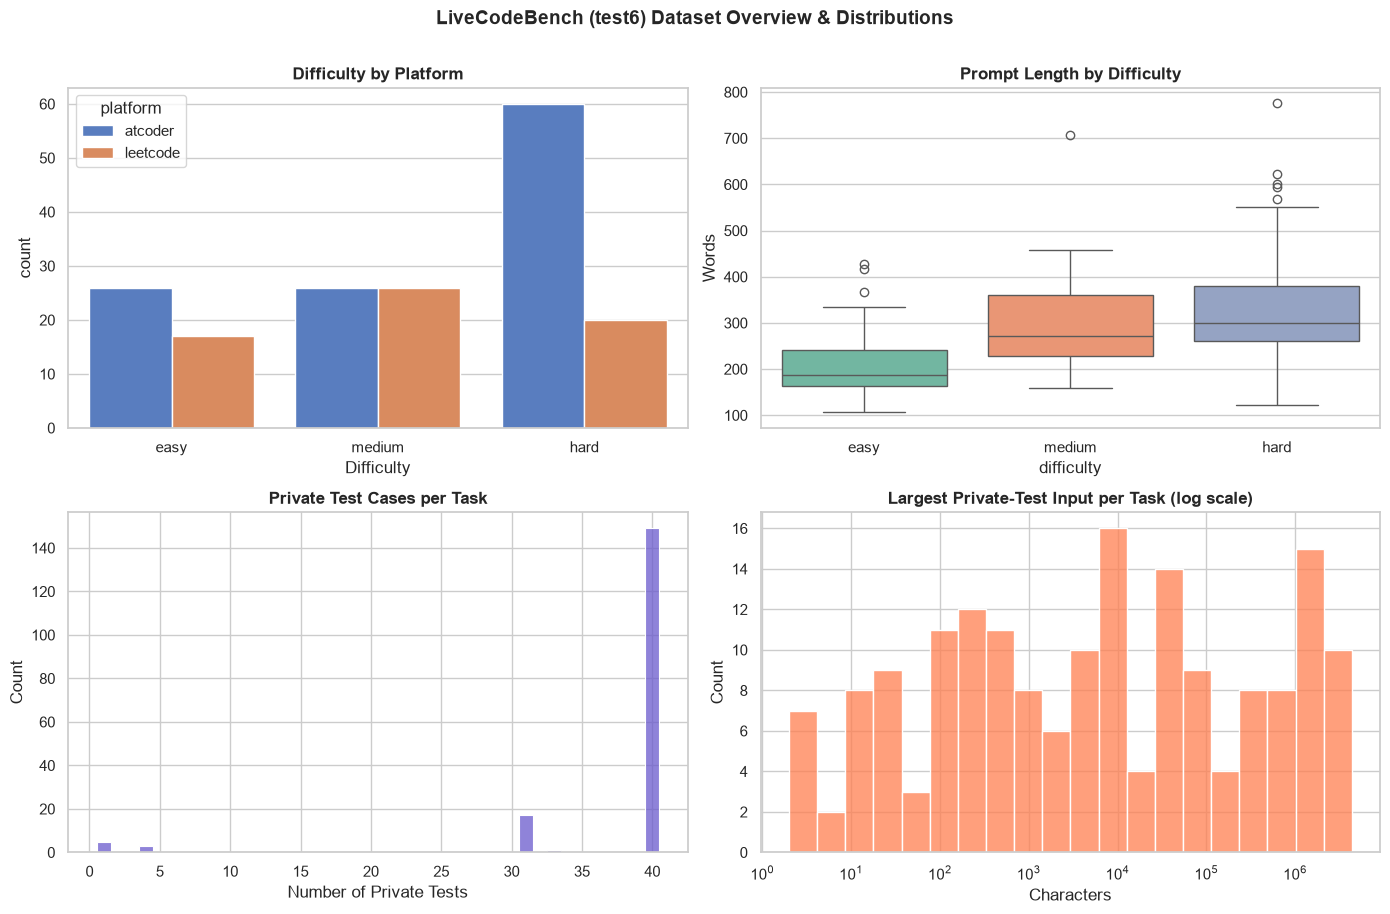

In [99]:
print("[INFO] Generating dataset metrics and distribution profiles...")

df_lcb_eda = df_lcb_clean.copy()
df_lcb_eda["prompt_word_len"] = df_lcb_eda["prompt"].astype(str).str.split().str.len()
df_lcb_eda["num_public_test_cases"] = df_lcb_eda["test_cases"].apply(len)
df_lcb_eda["num_private_test_cases"] = df_lcb_eda["private_test_cases"].apply(len)
# Largest single private-test input per task (characters); very large inputs stress efficiency.
df_lcb_eda["max_private_input_chars"] = df_lcb_eda["private_test_cases"].apply(
    lambda tests: max((len(t.get("input", "")) for t in tests), default=0)
)

metrics = ["prompt_word_len", "num_public_test_cases", "num_private_test_cases", "max_private_input_chars"]
lcb_stats_df = df_lcb_eda[metrics].describe().T[["count", "mean", "std", "min", "50%", "max"]]
lcb_stats_df.columns = ["Count", "Mean", "Std Dev", "Min", "Median", "Max"]

print("--- LiveCodeBench Summary Statistics ---")
print(lcb_stats_df.round(2).to_string())
lcb_stats_df.to_csv(REPORTS_DIR / "livecodebench_summary_statistics.csv")

# Difficulty x platform: test6 is skewed toward hard problems, so per-difficulty breakdowns matter.
difficulty_order = ["easy", "medium", "hard"]
lcb_crosstab = pd.crosstab(df_lcb_eda["difficulty"], df_lcb_eda["platform"], margins=True)
lcb_crosstab = lcb_crosstab.reindex(difficulty_order + ["All"])
print("\n--- Difficulty x Platform ---")
print(lcb_crosstab.to_string())
lcb_crosstab.to_csv(REPORTS_DIR / "livecodebench_difficulty_by_platform.csv")

# Flag tasks whose private inputs are extreme (top 5%), likely to hit evaluator timeouts.
input_threshold = df_lcb_eda["max_private_input_chars"].quantile(0.95)
extreme_inputs = df_lcb_eda[df_lcb_eda["max_private_input_chars"] > input_threshold]
print(f"\nTasks with extreme private-test inputs (> 95th pct, {input_threshold:,.0f} chars): {len(extreme_inputs)}")
print(extreme_inputs[["task_id", "platform", "difficulty", "max_private_input_chars"]].to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.countplot(data=df_lcb_eda, x="difficulty", hue="platform", order=difficulty_order, ax=axes[0, 0])
axes[0, 0].set_title("Difficulty by Platform", fontweight="bold")
axes[0, 0].set_xlabel("Difficulty")

sns.boxplot(data=df_lcb_eda, x="difficulty", y="prompt_word_len", order=difficulty_order, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Prompt Length by Difficulty", fontweight="bold")
axes[0, 1].set_ylabel("Words")

sns.histplot(df_lcb_eda["num_private_test_cases"], ax=axes[1, 0], color="slateblue", discrete=True)
axes[1, 0].set_title("Private Test Cases per Task", fontweight="bold")
axes[1, 0].set_xlabel("Number of Private Tests")

sns.histplot(df_lcb_eda["max_private_input_chars"], ax=axes[1, 1], color="coral", log_scale=True, bins=20)
axes[1, 1].set_title("Largest Private-Test Input per Task (log scale)", fontweight="bold")
axes[1, 1].set_xlabel("Characters")

plt.suptitle("LiveCodeBench (test6) Dataset Overview & Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()

plt.savefig(REPORTS_DIR / "livecodebench_eda_distributions.png", bbox_inches="tight")
plt.show()

# Trim to the evaluation subset

The EDA above describes all of test6; this step cuts it down to what we evaluate on.

- **Difficulty:** keep medium + hard. Easy problems overlap with what MBPP/HumanEval already cover, and hard-only would be too small (and risk a near-zero baseline).
- **Contamination:** `CONTEST_DATE_AFTER` keeps only problems released after a date. The baseline model (`claude-sonnet-4-6`) has a Jan 2026 cutoff, and test6 problems are from early 2025, so they may be contaminated. Leave it as `None` for test6; set it to `"2026-01-31"` if we switch to a newer LiveCodeBench release.
- **Private tests:** capped at `MAX_PRIVATE_TESTS` per task to keep evaluation runtime manageable. Selection is deterministic (per-task seed) and always keeps the `KEEP_LARGEST_INPUTS` largest inputs, since those catch slow solutions. Fewer tests make Pass@1 somewhat higher (more wrong solutions slip through), but every arm is scored on the same tests, so comparisons stay fair. Report this as "LCB, 10 private tests per task".

In [100]:
import random

# --- LCB subset settings ---
KEEP_DIFFICULTIES = ["medium", "hard"]  # easy is dropped: MBPP/HumanEval already cover easy problems
CONTEST_DATE_AFTER = None               # e.g. "2026-01-31" to keep only problems after the baseline model's cutoff
MAX_PRIVATE_TESTS = 10                  # cap per task to keep evaluation runtime manageable
KEEP_LARGEST_INPUTS = 3                 # always kept: the largest inputs catch slow solutions
SEED = 42


def cap_private_tests(tests: list, task_id: str) -> list:
    """
    Keeps the KEEP_LARGEST_INPUTS largest-input tests plus a seeded random sample of the rest,
    in their original order. The seed is per task, so every run selects the same tests.
    """
    if len(tests) <= MAX_PRIVATE_TESTS:
        return tests
    by_size = sorted(range(len(tests)), key=lambda i: len(tests[i].get("input", "")), reverse=True)
    keep = set(by_size[:KEEP_LARGEST_INPUTS])
    rest = [i for i in range(len(tests)) if i not in keep]
    keep.update(random.Random(f"{SEED}-{task_id}").sample(rest, MAX_PRIVATE_TESTS - len(keep)))
    return [tests[i] for i in sorted(keep)]


n_before = len(df_lcb_clean)
subset_mask = df_lcb_clean["difficulty"].isin(KEEP_DIFFICULTIES)
if CONTEST_DATE_AFTER:
    subset_mask &= df_lcb_clean["contest_date"] > CONTEST_DATE_AFTER  # ISO strings compare correctly
df_lcb_clean = df_lcb_clean[subset_mask].reset_index(drop=True)

# Record the original count once, so re-running this cell doesn't overwrite it with the capped count
if "num_private_test_cases_original" not in df_lcb_clean.columns:
    df_lcb_clean["num_private_test_cases_original"] = df_lcb_clean["private_test_cases"].apply(len)
df_lcb_clean["private_test_cases"] = [
    cap_private_tests(tests, task_id)
    for tests, task_id in zip(df_lcb_clean["private_test_cases"], df_lcb_clean["task_id"])
]

print(f"[INFO] LiveCodeBench subset: {len(df_lcb_clean)} / {n_before} tasks "
      f"(difficulty in {KEEP_DIFFICULTIES}, contest_date after {CONTEST_DATE_AFTER or 'any date'})")
print(f"[INFO] Private tests: {df_lcb_clean['num_private_test_cases_original'].sum():,} -> "
      f"{df_lcb_clean['private_test_cases'].apply(len).sum():,} (max {MAX_PRIVATE_TESTS} per task, "
      f"{KEEP_LARGEST_INPUTS} largest inputs always kept)")
print(f"[INFO] Usable tasks in subset: {df_lcb_clean['tests_ok'].sum()} / {len(df_lcb_clean)}")
pd.crosstab(df_lcb_clean["difficulty"], df_lcb_clean["platform"], margins=True)

[INFO] LiveCodeBench subset: 132 / 175 tasks (difficulty in ['medium', 'hard'], contest_date after any date)
[INFO] Private tests: 4,970 -> 1,257 (max 10 per task, 3 largest inputs always kept)
[INFO] Usable tasks in subset: 131 / 132


platform,atcoder,leetcode,All
difficulty,,,
hard,60,20,80
medium,26,26,52
All,86,46,132


# Processed Data and Export to file

`test_cases` (public tests) and all metadata go into the light parquet/CSV files. Private tests are written separately to `livecodebench_private_tests.jsonl`, which is git-ignored. Where the evaluator gets them from (this file, Drive, or Hugging Face at scoring time) is still a team decision.

In [101]:
df_lcb_clean["num_private_test_cases"] = df_lcb_clean["private_test_cases"].apply(len)
df_lcb_verified = df_lcb_clean[df_lcb_clean["tests_ok"]].reset_index(drop=True)

# Light files: everything except the private tests, small enough for git and Colab.
# Private tests can be very large (big stdin inputs), so they go to a separate, git-ignored JSONL keyed by task_id.
lcb_light_cols = [c for c in df_lcb_clean.columns if c != "private_test_cases"]
df_lcb_full_light = df_lcb_clean[lcb_light_cols].copy()
df_lcb_verified_light = df_lcb_verified[lcb_light_cols].copy()

df_lcb_full_light["test_cases_json"] = df_lcb_full_light["test_cases"].apply(test_cases_to_json)
df_lcb_verified_light["test_cases_json"] = df_lcb_verified_light["test_cases"].apply(test_cases_to_json)

df_lcb_full_light.to_parquet(PROCESSED_DIR / "livecodebench_full.parquet", index=False)
df_lcb_verified_light.to_parquet(PROCESSED_DIR / "livecodebench_verified.parquet", index=False)
df_lcb_verified_light.to_csv(PROCESSED_DIR / "livecodebench_verified.csv", index=False)

lcb_private_path = PROCESSED_DIR / "livecodebench_private_tests.jsonl"
df_lcb_clean[["task_id", "private_test_cases"]].to_json(lcb_private_path, orient="records", lines=True)

print(f"[SUCCESS] Artifacts stored in '{PROCESSED_DIR.resolve()}':")
print(f"          - Full Dataset: livecodebench_full.parquet ({len(df_lcb_full_light)} rows)")
print(f"          - Verified Dataset: livecodebench_verified.parquet ({len(df_lcb_verified_light)} rows)")
print(f"          - Private tests (git-ignored): {lcb_private_path.name} "
      f"({lcb_private_path.stat().st_size / 1e6:,.1f} MB)")

[SUCCESS] Artifacts stored in '/Users/diadana/Documents/GitHub/Anote-1A-building-high-quality-datasets-and-evaluation-frameworks-for-ai-coding-assistants/notebooks/data/processed':
          - Full Dataset: livecodebench_full.parquet (132 rows)
          - Verified Dataset: livecodebench_verified.parquet (131 rows)
          - Private tests (git-ignored): livecodebench_private_tests.jsonl (189.9 MB)


# -- Unified Code Generation Dataset --

Combines the verified MBPP, HumanEval and LiveCodeBench tasks using the field names `Evaluator/evaluator.py` expects. Each dataset stays identifiable by `source`, so results should always be reported per source; one file does not mean pooling them into one score.

**Two outputs:**
1. `code_generation_eval.jsonl`: what the evaluator needs.
   - Evaluator fields: `id`, `task_type`, `source`, `prompt`, `reference`, `tests`.
   - Plus `test_format` and `entry_point`, which tell the evaluator which test runner to use (LiveCodeBench's input/output tests need their own).
2. `code_generation_full.parquet` / `.csv`: everything, for EDA and failure analysis.
   - Shared columns: `signature`, `difficulty`, `num_tests`, `is_valid`, `verification_error`.
   - LiveCodeBench-only columns are prefixed `lcb_` (empty for other sources).

**Field mapping:** `task_id` → `id` (e.g. `mbpp-602`), `dataset_name` → `source` (lowercase), `reference_code` → `reference`, `test_cases` → `tests`, `task_type` → `code_generation`. MBPP's `test_imports` is prepended to each of its tests, since the evaluator has no separate setup field.

In [102]:
EVAL_COLS = ["id", "task_type", "source", "prompt", "reference", "tests"]  # Evaluator/evaluator.py item schema
RUNNER_COLS = ["test_format", "entry_point"]       # needed to pick and run the right test runner (LCB)
SHARED_COLS = ["signature", "difficulty", "num_tests", "is_valid", "verification_error"]
LCB_COLS = ["lcb_platform", "lcb_contest_id", "lcb_contest_date",
            "lcb_num_private_tests", "lcb_num_private_tests_original"]


def to_list(x) -> list:
    """Parquet-loaded test lists come back as numpy arrays; the evaluator expects plain lists."""
    return x.tolist() if isinstance(x, np.ndarray) else list(x)


def base_frame(df: pd.DataFrame, source: str) -> pd.DataFrame:
    """Columns that map the same way for every code generation dataset."""
    out = pd.DataFrame()
    # "MBPP/602" -> "mbpp-602", "HumanEval/0" -> "humaneval-0", "LCB/abc387_b" -> "livecodebench-abc387_b"
    out["id"] = source + "-" + df["task_id"].str.split("/", n=1).str[1]
    out["task_type"] = "code_generation"
    out["source"] = source
    out["prompt"] = df["prompt"]
    out["reference"] = df["reference_code"]
    out["test_format"] = df["test_format"]
    out["entry_point"] = df["entry_point"]
    out["signature"] = df["signature"]
    out["verification_error"] = df["verification_error"]
    return out


# MBPP: the evaluator has no setup field, so prepend test_imports to every assert (as evaluator.from_mbpp does)
mbpp_unified = base_frame(df_mbpp_verified, "mbpp")
mbpp_unified["tests"] = [
    [(imports + "\n" + t).strip() for t in to_list(tests)]
    for imports, tests in zip(df_mbpp_verified["test_imports"], df_mbpp_verified["test_cases"])
]
mbpp_unified["num_tests"] = mbpp_unified["tests"].apply(len)
mbpp_unified["difficulty"] = None
mbpp_unified["is_valid"] = df_mbpp_verified["is_valid_reference"]

# HumanEval: tests are already [check() source + check(entry_point)]
he_unified = base_frame(df_humaneval_verified, "humaneval")
he_unified["tests"] = df_humaneval_verified["test_cases"].apply(to_list)
he_unified["num_tests"] = he_unified["tests"].apply(
    lambda tests: sum(isinstance(node, ast.Assert) for t in tests for node in ast.walk(ast.parse(t)))
)
he_unified["difficulty"] = None
he_unified["is_valid"] = df_humaneval_verified["is_valid_reference"]

# LiveCodeBench: tests are the public input/output pairs; private tests stay in livecodebench_private_tests.jsonl
lcb_unified = base_frame(df_lcb_verified, "livecodebench")
lcb_unified["tests"] = df_lcb_verified["test_cases"].apply(to_list)
lcb_unified["num_tests"] = df_lcb_verified["test_cases"].apply(len) + df_lcb_verified["num_private_test_cases"]
lcb_unified["difficulty"] = df_lcb_verified["difficulty"]
lcb_unified["is_valid"] = df_lcb_verified["tests_ok"]
lcb_unified["lcb_platform"] = df_lcb_verified["platform"]
lcb_unified["lcb_contest_id"] = df_lcb_verified["contest_id"]
lcb_unified["lcb_contest_date"] = df_lcb_verified["contest_date"]
lcb_unified["lcb_num_private_tests"] = df_lcb_verified["num_private_test_cases"]
lcb_unified["lcb_num_private_tests_original"] = df_lcb_verified["num_private_test_cases_original"]

df_codegen_full = pd.concat([mbpp_unified, he_unified, lcb_unified], ignore_index=True)
df_codegen_full = df_codegen_full[EVAL_COLS + RUNNER_COLS + SHARED_COLS + LCB_COLS]
assert df_codegen_full["id"].is_unique, "Duplicate ids across datasets"

# 1) Evaluator file: only what scoring needs. JSONL keeps `tests` as real lists
#    (MBPP/HumanEval: code strings; LiveCodeBench: input/output dicts).
eval_path = PROCESSED_DIR / "code_generation_eval.jsonl"
df_codegen_full[EVAL_COLS + RUNNER_COLS].to_json(eval_path, orient="records", lines=True)

# 2) Full/EDA file: every column; tests stored as a JSON string so parquet/CSV can hold the mixed formats.
df_codegen_export = df_codegen_full.copy()
df_codegen_export["tests"] = df_codegen_export["tests"].apply(json.dumps)
df_codegen_export.to_parquet(PROCESSED_DIR / "code_generation_full.parquet", index=False)
df_codegen_export.to_csv(PROCESSED_DIR / "code_generation_full.csv", index=False)

print("=== Unified Code Generation Dataset ===")
print(df_codegen_full["source"].value_counts().reindex(["mbpp", "humaneval", "livecodebench"]).to_string())
print(f"Total tasks: {len(df_codegen_full)}")
print(f"\n[SUCCESS] Artifacts stored in '{PROCESSED_DIR.resolve()}':")
print(f"          - Evaluator file: {eval_path.name} ({len(EVAL_COLS + RUNNER_COLS)} columns)")
print(f"          - Full/EDA file: code_generation_full.parquet / .csv ({df_codegen_full.shape[1]} columns)")
print(f"          - LiveCodeBench private tests (unchanged): livecodebench_private_tests.jsonl")

=== Unified Code Generation Dataset ===
source
mbpp             377
humaneval        164
livecodebench    131
Total tasks: 672

[SUCCESS] Artifacts stored in '/Users/diadana/Documents/GitHub/Anote-1A-building-high-quality-datasets-and-evaluation-frameworks-for-ai-coding-assistants/notebooks/data/processed':
          - Evaluator file: code_generation_eval.jsonl (8 columns)
          - Full/EDA file: code_generation_full.parquet / .csv (18 columns)
          - LiveCodeBench private tests (unchanged): livecodebench_private_tests.jsonl


# Side-by-Side EDA

**Comparability notes:**
- Prompts differ by design: MBPP is one sentence + signature, HumanEval is a code stub with docstring, LiveCodeBench is a full contest statement. Prompt length is on a log scale for this reason.
- `num_tests` units differ: MBPP counts asserts, HumanEval counts asserts inside `check()`, LiveCodeBench counts input/output pairs (public + capped private).
- Only MBPP and HumanEval have reference solutions; HumanEval's LOC includes its docstring.
- Only LiveCodeBench has difficulty labels; MBPP/HumanEval show as "unlabeled".

[INFO] Generating cross-dataset comparison...
--- Code Generation: Summary Statistics by Source ---
source                   mbpp  humaneval  livecodebench
prompt_word_len count  377.00     164.00         131.00
                mean    19.21      67.72         315.62
                std      7.35      38.67         114.79
                min      9.00      17.00         122.00
                25%     15.00      39.00         238.00
                50%     18.00      60.00         291.00
                75%     21.00      83.25         367.50
                max     81.00     249.00         776.00
num_tests       count  377.00     164.00         131.00
                mean     3.10       7.20          12.23
                std      0.42       3.72           2.22
                min      3.00       1.00           2.00
                25%      3.00       5.00          12.00
                50%      3.00       7.00          13.00
                75%      3.00       9.00          13.00
    

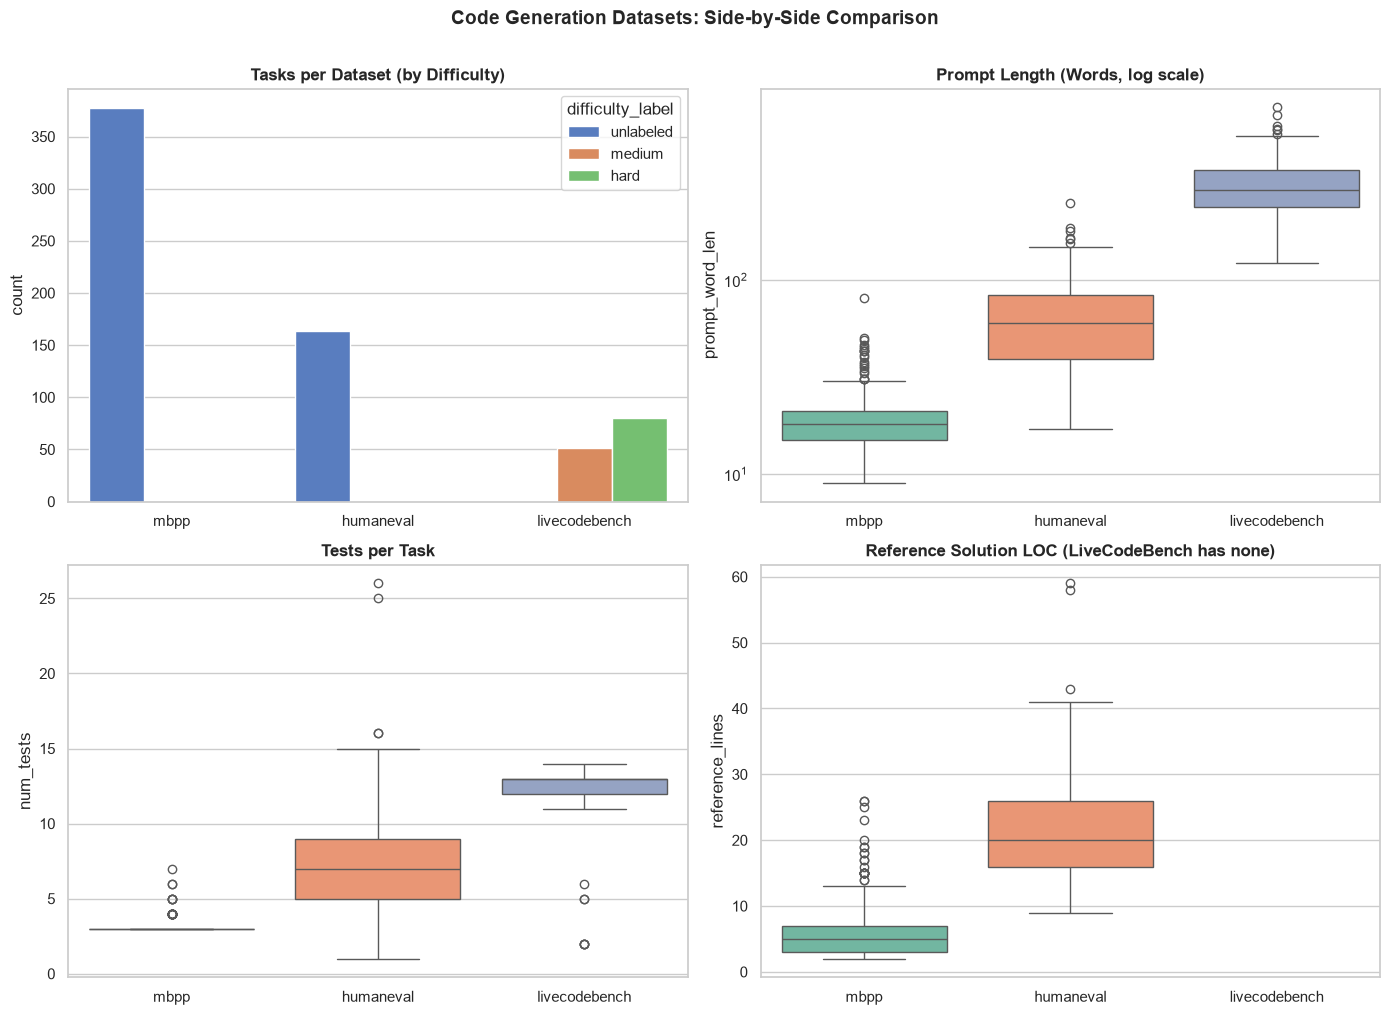

In [103]:
print("[INFO] Generating cross-dataset comparison...")

source_order = ["mbpp", "humaneval", "livecodebench"]
df_cg_eda = df_codegen_full.copy()
df_cg_eda["prompt_word_len"] = df_cg_eda["prompt"].astype(str).str.split().str.len()
# LiveCodeBench has no references, so its reference length is left empty rather than 0
df_cg_eda["reference_lines"] = df_cg_eda["reference"].str.split("\n").str.len().where(df_cg_eda["reference"] != "")
df_cg_eda["difficulty_label"] = df_cg_eda["difficulty"].fillna("unlabeled")

cg_stats_df = (
    df_cg_eda.groupby("source")[["prompt_word_len", "num_tests", "reference_lines"]]
    .describe()
    .reindex(source_order)
)
print("--- Code Generation: Summary Statistics by Source ---")
print(cg_stats_df.round(2).T.to_string())
cg_stats_df.to_csv(REPORTS_DIR / "code_generation_summary_by_source.csv")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df_cg_eda, x="source", hue="difficulty_label", order=source_order,
              hue_order=["unlabeled", "medium", "hard"], ax=axes[0, 0])
axes[0, 0].set_title("Tasks per Dataset (by Difficulty)", fontweight="bold")
axes[0, 0].set_xlabel("")

sns.boxplot(data=df_cg_eda, x="source", y="prompt_word_len", order=source_order, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Prompt Length (Words, log scale)", fontweight="bold")
axes[0, 1].set_xlabel("")

sns.boxplot(data=df_cg_eda, x="source", y="num_tests", order=source_order, ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Tests per Task", fontweight="bold")
axes[1, 0].set_xlabel("")

sns.boxplot(data=df_cg_eda, x="source", y="reference_lines", order=source_order, ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Reference Solution LOC (LiveCodeBench has none)", fontweight="bold")
axes[1, 1].set_xlabel("")

plt.suptitle("Code Generation Datasets: Side-by-Side Comparison", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()

plt.savefig(REPORTS_DIR / "code_generation_comparison.png", bbox_inches="tight")
plt.show()

**Note: LiveCodeBench has no reference solutions**

LiveCodeBench is scored on Pass@1 only. CodeBLEU, AST-diff and exact-match are reported for MBPP and HumanEval only, since they need a reference to compare against.

- **Why this is acceptable:** for contest problems, correctness and efficiency are measured by the hidden tests (the largest inputs are kept, so slow solutions time out). A single reference would add a similarity score, not a better correctness signal, since many different algorithms are correct.
- **If we want references later**, the cheapest option is to have a strong model (one we are *not* evaluating) write a solution per task and keep it only if it passes all of LCB's original private tests. This needs the stdin/functional test runner first. Human solutions (AtCoder editorials/submissions, open LeetCode solution repos) are possible but slower, and need license checks; scraping LeetCode is against its terms.